# Import Library

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_ai4i_data

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
output_dir = '../reports/figures'
os.makedirs(output_dir, exist_ok=True)

# Load Dataset

In [3]:
df = load_ai4i_data()
display(df.head())

,udi,product_id,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# Correlation Heatmap

Invistigating linear relationships between all numerical sensor features.

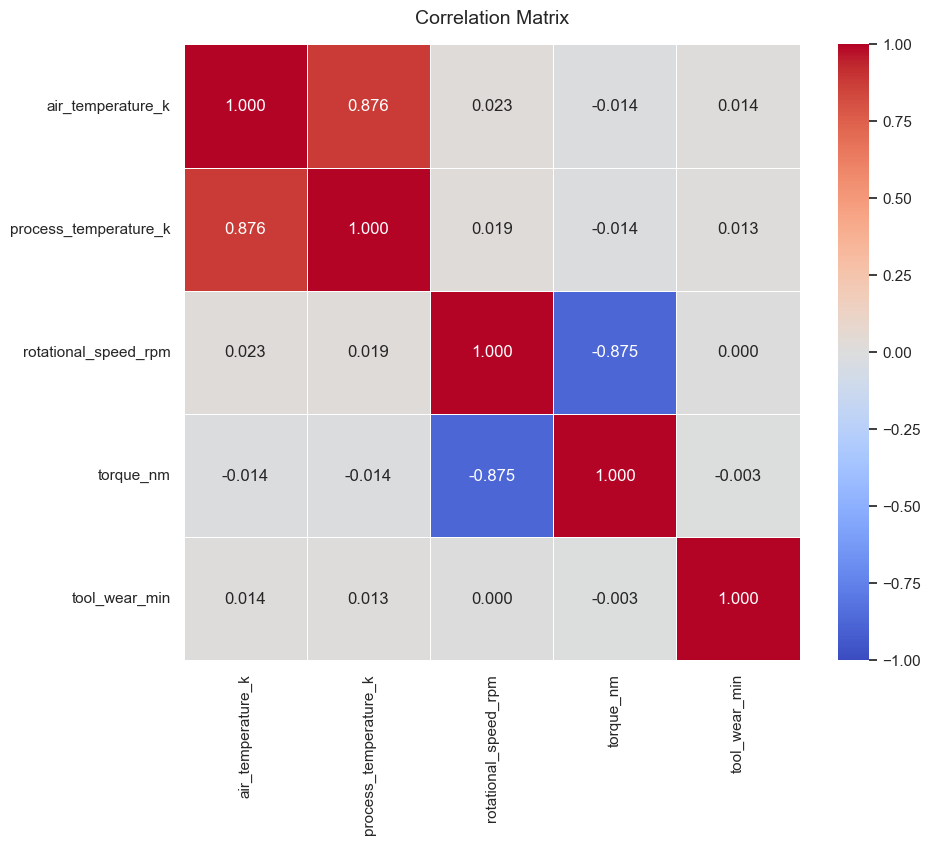

In [4]:
numeric_cols = [
    'air_temperature_k', 
    'process_temperature_k', 
    'rotational_speed_rpm', 
    'torque_nm', 
    'tool_wear_min'
]

corr_matrix = df[numeric_cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14, pad=15)

file_path = os.path.join(output_dir, "corr_matrix_pearson.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

- **Strong Positive Correlation (Air Temperature vs. Process Temperature):** The *air_temperature_k* and *process_temperature_k* features exhibit a **strong positive linear correlation** (**r = 0.876**). This indicates that increases in air temperature are generally accompanied by increases in process temperature, which is consistent with the dataset description that the process temperature is maintained at approximately **10 K** above the surrounding air temperature.

- **Strong Negative Correlation (Rotational Speed vs. Torque):** The *rotational_speed_rpm* and *torque_nm* features exhibit a **strong negative linear correlation** (**r = −0.875**). This indicates that higher rotational speeds are generally associated with lower torque values, while lower rotational speeds tend to correspond to higher torque values. This inverse relationship reflects the expected operating characteristics of industrial rotating machinery.

- **Independence of Tool Wear:** The *tool_wear_min* feature shows correlation coefficients close to **zero** with all other operational variables. This suggests that tool wear has little to no linear relationship with air temperature, process temperature, rotational speed, or torque, indicating that it varies largely independently of these operating conditions.

# Temperature Bivariate

Analyzing the exact linear boundary between ambient air and the machine's internal process temperature.

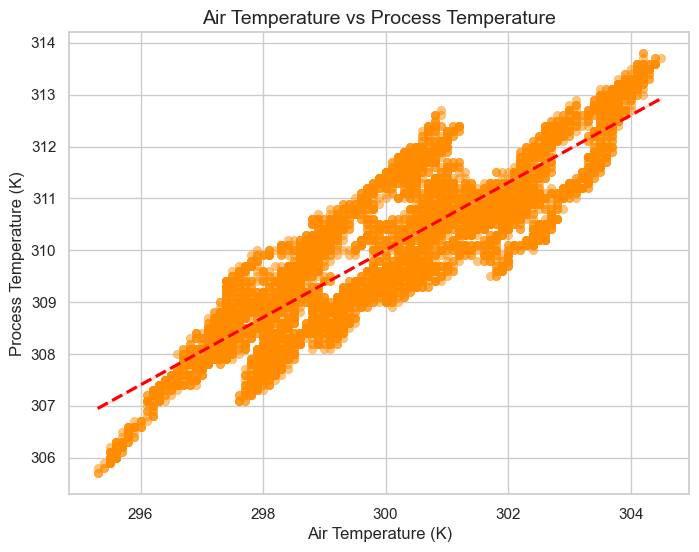

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='air_temperature_k', y='process_temperature_k', alpha=0.5, color='darkorange', edgecolor=None)

sns.regplot(data=df, x='air_temperature_k', y='process_temperature_k', scatter=False, color='red', line_kws={"linestyle": "--"})

plt.title("Air Temperature vs Process Temperature", fontsize=14)
plt.xlabel("Air Temperature (K)")
plt.ylabel("Process Temperature (K)")

file_path = os.path.join(output_dir, "scatter_temperatures.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

- **Strong Positive Linear Relationship:** The scatter plot shows a clear positive linear relationship between *air_temperature_k* and *process_temperature_k*. As the air temperature increases, the process temperature also increases proportionally, confirming the strong positive correlation observed in the Pearson correlation analysis.

- **Consistent Temperature Difference:** The observations form several parallel bands rather than a single straight line, indicating a relatively consistent temperature difference between air and process temperatures. This pattern is consistent with the dataset description, where the process temperature is maintained at approximately **10 K** above the air temperature.

- **Stable Thermal Behavior:** No significant deviations from the overall trend are observed, suggesting that the thermal operating conditions remain consistent across the majority of the dataset.

# Bivariate of Motor Dynamics: Speed & Torque

Investigating the non-linear operational boundary of the industrial motor.

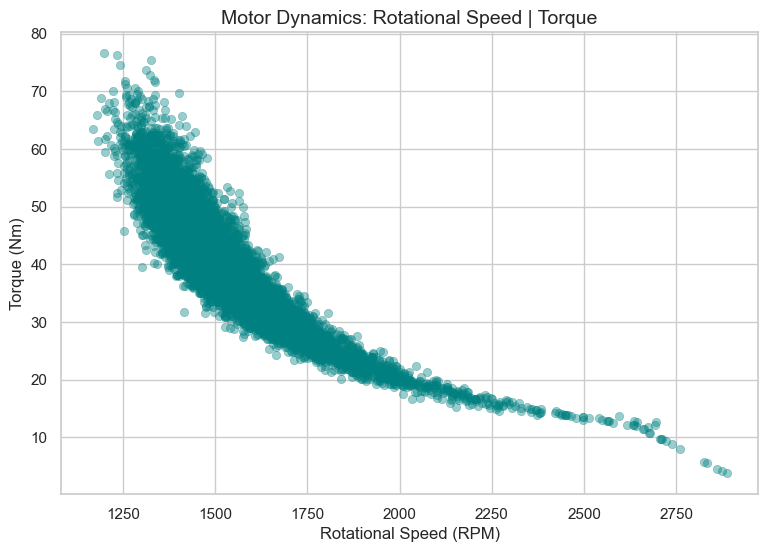

In [6]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='rotational_speed_rpm', y='torque_nm', alpha=0.4, color='teal', edgecolor=None)

plt.title("Motor Dynamics: Rotational Speed | Torque", fontsize=14)
plt.xlabel("Rotational Speed (RPM)")
plt.ylabel("Torque (Nm)")

file_path = os.path.join(output_dir, "scatter_speed_torque.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

- **Strong Inverse Relationship:** The scatter plot demonstrates a strong negative relationship between *rotational_speed_rpm* and *torque_nm*, where higher rotational speeds are generally associated with lower torque values.

- **Curved Operating Pattern:** The observations form a distinct non-linear pattern rather than a straight line, indicating that the relationship between rotational speed and torque is not purely linear.

- **Potential Extreme Conditions:** A small number of observations lie outside the main operating region, particularly at very high rotational speeds and extreme torque values, suggesting uncommon operating conditions that will be further investigated.

# Product Quality vs Tool Wear

Does product quality variant (L/M/H) affect how long the tool operates?

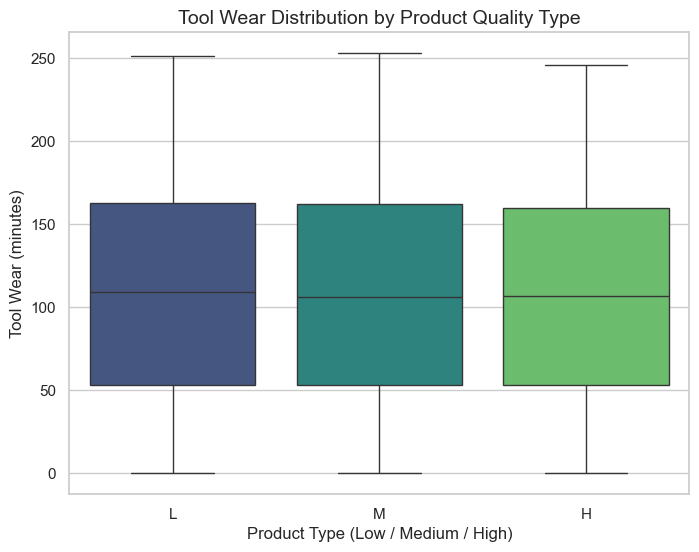

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='type', y='tool_wear_min', order=['L', 'M', 'H'], palette='viridis')

plt.title("Tool Wear Distribution by Product Quality Type", fontsize=14)
plt.xlabel("Product Type (Low / Medium / High)")
plt.ylabel("Tool Wear (minutes)")

file_path = os.path.join(output_dir, "boxplot_toolwear_by_type.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

- **Uniform Tool Wear Distribution:** The boxplots show that the median (approximately **108 minutes**) and the Interquartile Range (IQR) of *tool_wear_min* are highly similar across all three product quality categories (*L*, *M*, and *H*). The upper and lower whiskers also exhibit nearly identical ranges, with no apparent outliers observed in any category.

- **Consistent Tool Replacement Pattern:** Despite the dataset documentation stating that product variants *H*, *M*, and *L* increase tool wear by **5**, **3**, and **2 minutes** per process, respectively, the overall distribution of accumulated tool wear remains comparable across all product types. Most observations fall within a similar operating range, with maximum values approaching the expected tool replacement threshold.